# Exploração do dataset MedQuAD

Um breve tratamento e exploração dos pares de perguntas e respostas MedQuAD classificados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "assets/QA-TestSet-LiveQA-Med-Qrels-2479-Answers/All-qrels_LiveQAMed2017-TestQuestions_2479_Judged-Answers.txt",
    # Apesar de ser um arquivo .txt, cada linha é um registro separado por espaço
    sep="\\s",
    engine="python",
    header=None,
    names=["qid", "score", "docid"],
)

df.head()

,qid,score,docid
0,1,1-Incorrect,ADAM_0003147_Sec1.txt
1,1,1-Incorrect,ADAM_0003147_Sec2.txt
2,1,2-Related,ADAM_0002818_Sec2.txt
3,1,2-Related,ADAM_0002818_Sec7.txt
4,1,2-Related,ADAM_0002818_Sec9.txt


Vamos verificar a distribuição de pares considerando sua classificação.

<Axes: xlabel='score'>

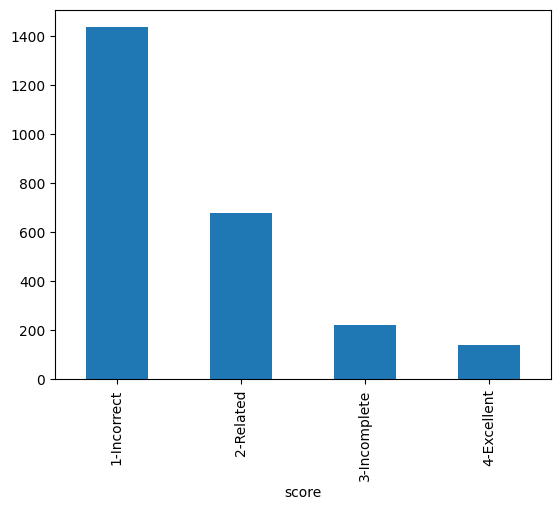

In [3]:
df["score"].value_counts().plot.bar()

O dataset é dominado por pares de perguntas e respostas incorretas, com menos de 200 exemplos corretos e pouco mais de 200 parcialmente respondidos (incompletos.)

Para poder avaliar se usamos apenas as respostas de classificação 4 ou combinamos com classificação 3, vamos enriquecer o dataset com o conteúdo efetivo das perguntas e respostas.

## Reconstruindo o dataset

In [4]:
df_qa = pd.read_csv(
    "assets/QA-TestSet-LiveQA-Med-Qrels-2479-Answers/All-2479-Answers-retrieved-from-MedQuAD.csv"
)

df_qa.head()

,AnswerID,Answer
0,ADAM_0003147_Sec1.txt,Question: What is (are) Polycystic ovary syndr...
1,ADAM_0003147_Sec2.txt,Question: What causes Polycystic ovary syndrom...
2,ADAM_0002818_Sec2.txt,Question: What causes Noonan syndrome ?\nURL: ...
3,ADAM_0002818_Sec7.txt,Question: What are the complications of Noonan...
4,ADAM_0002818_Sec9.txt,Question: How to prevent Noonan syndrome ?\nUR...


A coluna "Answer" na verdade contém três informações: Questions, URL e Answer (Pergunta, URL de onde foi extraída a resposta, e a Resposta efetivamente).

Vamos separar estas colunas pois precisaremos traduzir as perguntas e respostas para o português. Não queremos desperdicar tokens traduzindo URLs e queremos maior controle sobre como apresentaremos exemplos de interações no nosso fine tuning.

In [5]:
df_qa["Original_QA"] = df_qa["Answer"]

import re

# Ideia: vamos verificar se todos os pares de pergunta e resposta possuem uma URL separando cada elemento.

# Filtra apenas as linhas onde a coluna 'Answer' contém o padrão "URL: .+\n"
mask = df_qa["Answer"].str.contains(r"URL: .+\n", regex=True)
df_qa_with_url = df_qa[mask]

# Compara o número total de registros com o número de registros que correspondem ao padrão
total_records = len(df_qa)
matching_records = df_qa_with_url.shape[0]
print(f"Número total de registros: {total_records}")
print(f"Número de registros com padrão 'URL: .+\\n': {matching_records}")

assert total_records == matching_records

Número total de registros: 2479
Número de registros com padrão 'URL: .+\n': 2479


In [6]:
# Confirmado; procedendo usando a linha da URL como separador.

df_qa[["Question", "Answer"]] = (
    df_qa["Original_QA"]
    .str.split(r"URL: .+\n", expand=True)
    # e removendo os prefixos Question: e Answer:
    .apply(lambda x: x.str.replace(r"^(Question|Answer):\s*", "", regex=True).str.strip())
)
df_qa.head()

,AnswerID,Answer,Original_QA,Question
0,ADAM_0003147_Sec1.txt,Polycystic ovary syndrome is a condition in wh...,Question: What is (are) Polycystic ovary syndr...,What is (are) Polycystic ovary syndrome ? (Als...
1,ADAM_0003147_Sec2.txt,PCOS is linked to changes in hormone levels th...,Question: What causes Polycystic ovary syndrom...,What causes Polycystic ovary syndrome ? (Also ...
2,ADAM_0002818_Sec2.txt,Noonan syndrome is linked to defects in severa...,Question: What causes Noonan syndrome ?\nURL: ...,What causes Noonan syndrome ?
3,ADAM_0002818_Sec7.txt,- Buildup of fluid in tissues of body (lymphed...,Question: What are the complications of Noonan...,What are the complications of Noonan syndrome ?
4,ADAM_0002818_Sec9.txt,Couples with a family history of Noonan syndro...,Question: How to prevent Noonan syndrome ?\nUR...,How to prevent Noonan syndrome ?


## Avaliando respostas incompletas

Agora sim, vamos avaliar alguns exemplos de respostas incompletas antes de determinar se as usaremos também no fine tuning ou não.

In [7]:
merged_df = pd.merge(df_qa, df, left_on="AnswerID", right_on="docid")
merged_df.drop(columns=["docid", "Original_QA"], inplace=True)

with pd.option_context("display.max_colwidth", None):
    display(
        merged_df[merged_df["score"] == "3-Incomplete"].sample(n=5, random_state=42)
    )

AnswerID  \
3104               ADAM_0000455_Sec1.txt   
639                ADAM_0001588_Sec2.txt   
3432  MPlusHealthTopics_0000681_Sec1.txt   
2626         MPlusDrugs_0000583_Sec4.txt   
1121         MPlusDrugs_0000203_Sec6.txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

Mmm... talvez seja melhor ignorar estas respostas. Não apenas são incompletas, como trazem muita informação que pode sobrecarregar o médico durante o atendimento, indo contra o propósito de um assistente dessa natureza.

## Limpando o dataset

Uma coisa chamou atenção: há menções a números dos Estados Unidos. Vamos verificar se no conjunto de respostas completas há menções a este país e avaliar se precisamos de algum tratamento nesse sentido.

In [8]:
df_excellent_but_us = merged_df[
    (merged_df["score"] == "4-Excellent")
    & (merged_df["Answer"].str.contains(r"United\s+States", regex=True))
]

print(f"Número de respostas perfeitas que mencionam os EUA: {df_excellent_but_us.shape[0]}")

with pd.option_context("display.max_colwidth", 500, "display.max_rows", 20):
    display(
        df_excellent_but_us.head(20)
    )


Número de respostas perfeitas que mencionam os EUA: 6


,AnswerID,Answer,Question,qid,score
2392,ADAM_0001941_Sec2.txt,Hepatitis C infection is caused by the hepatitis C virus (HCV). You can catch hepatitis C if the blood of someone who has hepatitis C enters your body. Exposure may occur: - After a needle stick or sharps injury - If blood from someone who has hepatitis Ccontacts a cut on your skin or contacts your eyes or mouth People at risk of hepatitis C are those who: - Inject street drugs or share a needle with someone who has hepatitis C - Have been on long-term kidney dialysis - Have regul...,What causes Hepatitis C ? (Also called: Sustained virologic response - hepatitis C; SVR - hepatitis C),55,4-Excellent
2467,CDC_0000212_Sec4.txt,"The ""First""Outbreak\n \nIn May 1993, an outbreak of an unexplained pulmonary illness occurred in the southwestern United States, in an area shared by Arizona, New Mexico, Colorado and Utah known as ""The Four Corners"". A young, physically fit Navajo man suffering from shortness of breath was rushed to a hospital in New Mexico and died very rapidly.\n \n \nWhile reviewing the results of the case, medical personnel discovered that the young man's fiancée had died a few days before after sho...",what is the history of hps for Hantavirus ?,58,4-Excellent
2951,ADAM_0000920_Sec2.txt,It is called the common cold for good reason. There are over one billion colds in the United States each year. You and your children will probably have more colds than any other type of illness. Colds are the most common reason that children miss school and parents miss work. Parents often get colds from their children. Children can get many colds every year. They usually get them from other children. A cold can spread quickly through schools or daycares. Colds can occur at any time of th...,What causes Common cold ? (Also called: Upper respiratory infection - viral; Cold),70,4-Excellent
2958,ADAM_0000920_Sec2.txt,It is called the common cold for good reason. There are over one billion colds in the United States each year. You and your children will probably have more colds than any other type of illness. Colds are the most common reason that children miss school and parents miss work. Parents often get colds from their children. Children can get many colds every year. They usually get them from other children. A cold can spread quickly through schools or daycares. Colds can occur at any time of th...,What causes Common cold ? (Also called: Upper respiratory infection - viral; Cold),70,4-Excellent
3617,ADAM_0000642_Sec1.txt,Summary : WHO SHOULD TAKE CALCIUM SUPPLEMENTS? Calcium is an important mineral for the human body. It helps build and protect your teeth and bones. Getting enough calcium over your lifetime can help prevent osteoporosis. Most people get enough calcium in their normal diet. Dairy foods and leafy green vegetables have high levels of calcium. Older women and men may need extra calcium to prevent their bones from getting thin (osteoporosis). Your health care provider will tell you if you need...,Do you have information about Calcium supplements,85,4-Excellent
4313,ADAM_0000288_Sec2.txt,"As the aortic valve narrows, the left ventricle has to work harder to pump blood out through the valve. To do this extra work, the muscles in the ventricle walls become thicker. This can lead to chest pain. As the pressure continues to rise, blood may back up into the lungs. Severe aortic stenosis can limit the amount of blood that reaches the brain and the rest of the body. Aortic stenosis may be present from birth (congenital), but most often it develops later in life. Children with aor...",What causes Aortic stenosis ? (Also called: Aortic valve stenosis; Rheumatic aortic stenosis; Calcific aortic stenosis),102,4-Excellent


Dentro das respostas consideradas excelentes, há apenas 6 menções aos Estados Unidos - desde históricos de epidemias até menções a órgãos reguladores do país norte-americano. Como são poucos registros, vale seguir adiante com eles.

Outra coisa chamou atenção: parecem haver registros duplicados (coluna `qid`).

Vamos avaliar, considerando apenas as respostas escolhidas (4-Excellent).

In [9]:
# Identifica e exibe registros duplicados pelo valor da coluna 'qid'
df_excellent = merged_df[merged_df["score"] == "4-Excellent"]
duplicates = df_excellent[df_excellent.duplicated(subset=['qid'], keep="first")]
with pd.option_context("display.max_colwidth", 150):
    display(duplicates.sort_values(by="qid").head())

print(f"Número de registros excelentes: {df_excellent.shape[0]}")
print(f"Número de registros com qid duplicados: {duplicates.shape[0]}")

,AnswerID,Answer,Question,qid,score
123,ADAM_0003820_Sec5.txt,"Syphilis can be treated with antibiotics, such as: - Doxycycline - Penicillin G benzathine - Tetracycline (for patients who are allergic to pe...",What are the treatments for Syphilis - primary ? (Also called: Primary syphilis; Secondary syphilis; Late syphilis; Tertiary syphilis),4,4-Excellent
124,ADAM_0003820_Sec9.txt,"If you are sexually active, practice safe sex and always use a condom. All pregnant women should be screened for syphilis.)",How to prevent Syphilis - primary ? (Also called: Primary syphilis; Secondary syphilis; Late syphilis; Tertiary syphilis),4,4-Excellent
171,ADAM_0002332_Sec2.txt,"Injury to the laryngeal nerves is uncommon. When it does occur, it can be from: - A complication of neck or chest surgery (especially thyroid, l...",What causes Laryngeal nerve damage ? (Also called: Vocal cord paralysis),6,4-Excellent
358,ADAM_0001766_Sec2.txt,"GPA mainly affects blood vessels in the nose, sinuses, ears, lungs, and kidneys. Other areas may also be affected in some cases. The disease can b...",What causes Granulomatosis with polyangiitis ? (Also called: Formerly: Wegener's granulomatosis),9,4-Excellent
360,MPlusHealthTopics_0000855_Sec1.txt,"Strep is short for Streptococcus, a type of bacteria. There are two types: group A and group B. Group A strep causes - Strep throat - a s...",What is (are) Streptococcal Infections ? (Also called: Strep),9,4-Excellent


Número de registros excelentes: 223
Número de registros com qid duplicados: 173


In [10]:
df_excellent[df_excellent.duplicated()]

,AnswerID,Answer,Question,qid,score
171,ADAM_0002332_Sec2.txt,Injury to the laryngeal nerves is uncommon. W...,What causes Laryngeal nerve damage ? (Also cal...,6,4-Excellent
360,MPlusHealthTopics_0000855_Sec1.txt,"Strep is short for Streptococcus, a type of ba...",What is (are) Streptococcal Infections ? (Also...,9,4-Excellent
388,ADAM_0001177_Sec1.txt,Diabetes is a chronic disease in which the bod...,What is (are) Diabetes ? (Also called: Diabete...,82,4-Excellent
447,ADAM_0002492_Sec2.txt,The retina is at the back of the eye. It chang...,What causes Macular degeneration - age-related...,11,4-Excellent
449,GHR_0000027_Sec3.txt,Age-related macular degeneration results from ...,What are the genetic changes related to age-re...,11,4-Excellent
...,...,...,...,...,...
4225,ADAM_0000365_Sec4.txt,The health care provider will do a physical ex...,How to diagnose Autoimmune disorders ?,99,4-Excellent
4319,ADAM_0000288_Sec7.txt,Call your health care provider if you or your ...,Do I need to see a doctor for Aortic stenosis ...,102,4-Excellent
4321,GHR_0000962_Sec1.txt,Supravalvular aortic stenosis (SVAS) is a hear...,What is (are) supravalvular aortic stenosis ? ...,102,4-Excellent
4323,GHR_0000962_Sec3.txt,Mutations in the ELN gene cause SVAS. The ELN ...,What are the genetic changes related to suprav...,102,4-Excellent


Apesar de os `qid` aparecem duplicados, existem perguntas, respostas e classificações diferentes para cada valor. Não há muito o que tratar usando apenas este identificador.

Entretanto, podemos excluir os registros onde todos os valores estão duplicados.

In [11]:
original_count = df_excellent.shape[0]
df_excellent = df_excellent.drop_duplicates()
new_count = df_excellent.shape[0]

print(f"Número de registros removidos: {original_count - new_count}")
print(f"Número de registros excelentes após exclusão de duplicados: {new_count}")

df_excellent.head()

Número de registros removidos: 81
Número de registros excelentes após exclusão de duplicados: 142


,AnswerID,Answer,Question,qid,score
122,ADAM_0003820_Sec4.txt,The doctor or nurse will examine you. Tests th...,How to diagnose Syphilis - primary ? (Also cal...,4,4-Excellent
123,ADAM_0003820_Sec5.txt,"Syphilis can be treated with antibiotics, such...",What are the treatments for Syphilis - primary...,4,4-Excellent
124,ADAM_0003820_Sec9.txt,"If you are sexually active, practice safe sex ...",How to prevent Syphilis - primary ? (Also call...,4,4-Excellent
155,ADAM_0002332_Sec2.txt,Injury to the laryngeal nerves is uncommon. W...,What causes Laryngeal nerve damage ? (Also cal...,6,4-Excellent
357,MPlusHealthTopics_0000855_Sec1.txt,"Strep is short for Streptococcus, a type of ba...",What is (are) Streptococcal Infections ? (Also...,9,4-Excellent


Pronto! Apesar do número final relativamente baixo (apenas 142 pares), podemos prosseguir com a tradução do dataset filtrado, encontrado na variável `df_excellent`.

# Traduzindo o dataset

Vamos usar uma LLM para traduzir as perguntas para o portugês brasileiro, preservando o tom médico.

Começaremos testando com apenas um par.

In [12]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama

MODEL= "gemma4:e4b-it-q4_K_M"

llm = ChatOllama(model=MODEL, temperature=0.1)

translation_prompt = ChatPromptTemplate.from_messages([
    (   
        "system", 
        "Você é um tradutor de textos médicos."
        "Seu objetivo é traduzir as perguntas e respostas para o português brasileiro, preservando o tom médico."
        "Responda diretamente, sem explicações."
        "Responda com 'Pergunta:' e 'Resposta:'"
    ),
    (
        "user",
        "Question: {question}"
        "-----"
        "Answer: {answer}"
    ),
])

translation_chain = translation_prompt | llm | StrOutputParser()

question = df_excellent["Question"].iloc[0]
answer = df_excellent["Answer"].iloc[0]

result = translation_chain.invoke({
    "question": question,
    "answer": answer
})

print(f"Original question: {question}")
print(f"Original answer: {answer}")
print(f"Translated:\n{result}")

/Users/leanderseefeld/workspaces/fiap/8iadt-tc-fase3-assistente-medico/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


Original question: How to diagnose Syphilis - primary ? (Also called: Primary syphilis; Secondary syphilis; Late syphilis; Tertiary syphilis)
Original answer: The doctor or nurse will examine you. Tests that may be done include:  - Examination of fluid from sore  - Echocardiogram, aortic angiogram, and cardiac catheterization to look at the major blood vessels and the heart  - Spinal tap and examination of spinal fluid  - Blood tests to screen for syphillis bacteria (RPR, VDRL, or TRUST)    If the RPR, VDRL, or TRUST tests are positive, one of the following tests will be needed to confirm the diagnosis:   - FTA-ABS (fluorescent treponemal antibody test)  - MHA-TP  - TP-EIA  - TP-PA)
Translated:
Pergunta: Como diagnosticar sífilis primária? (Também chamado de: Sífilis primária; Sífilis secundária; Sífilis tardia; Sífilis terciária)
Resposta: O médico ou enfermeiro fará um exame físico. Os exames que podem ser realizados incluem: - Exame de fluido da lesão - Ecocardiograma, angiografia a

Parece satisfatório! Traduziu corretamente "spinal tap" para "punção lombar", ao invés de algo mais literal como "toque na espinha", o que pode indicar que o modelo base (Gemma4) possui algum corpus médico em seu treinamento inicial.

Vamos verificar as respostas que o modelo fundacional fornece antes do fine tuning para fins comparativos.

Mas antes, vamos criar um OutputParser customizado para facilitar comparações e extração das perguntas e respostas traduzidas em larga escala.

## OutputParser customizado

In [13]:
from dataclasses import dataclass
from langchain_core.output_parsers import BaseOutputParser

@dataclass
class QAOutput:
    pergunta: str
    resposta: str

    def __repr__(self):
        return f"Pergunta : {self.pergunta}\nResposta : {self.resposta}"

# ── Custom parser ──────────────────────────────────────────────
class PerguntaRespostaParser(BaseOutputParser[QAOutput]):
    """Parses output expected in 'Pergunta: ...\nResposta: ...' format."""

    def parse(self, text: str) -> QAOutput:
        match = re.search(
            r"Pergunta:\s*(.+?)\s*Resposta:\s*(.+)",
            text,
            re.IGNORECASE | re.DOTALL,
        )
        if not match:
            raise ValueError(f"Could not parse output:\n{text}")
        return QAOutput(pergunta=match.group(1).strip(), resposta=match.group(2).strip())

    @property
    def _type(self) -> str:
        return "pergunta_resposta_parser"

Executando o prompt anterior, desta vez com nosso parser para capturar a pergunta traduzida na saída.

In [14]:
translation_chain = translation_prompt | llm | PerguntaRespostaParser()

result = translation_chain.invoke({
    "question": question,
    "answer": answer
})

print(f"Original question: {question}")
print(f"Original answer: {answer}")

pergunta, resposta = result.pergunta, result.resposta
print(f"Pergunta: {pergunta}")
print(f"Resposta: {resposta}")

Original question: How to diagnose Syphilis - primary ? (Also called: Primary syphilis; Secondary syphilis; Late syphilis; Tertiary syphilis)
Original answer: The doctor or nurse will examine you. Tests that may be done include:  - Examination of fluid from sore  - Echocardiogram, aortic angiogram, and cardiac catheterization to look at the major blood vessels and the heart  - Spinal tap and examination of spinal fluid  - Blood tests to screen for syphillis bacteria (RPR, VDRL, or TRUST)    If the RPR, VDRL, or TRUST tests are positive, one of the following tests will be needed to confirm the diagnosis:   - FTA-ABS (fluorescent treponemal antibody test)  - MHA-TP  - TP-EIA  - TP-PA)
Pergunta: Como diagnosticar sífilis primária? (Também chamado de: Sífilis primária; Sífilis secundária; Sífilis tardia; Sífilis terciária)
Resposta: O médico ou enfermeiro fará um exame físico. Os exames que podem ser realizados incluem: - Exame de fluido da lesão - Ecocardiograma, angiografia aórtica e cat

## Avaliando o modelo base

Vamos fornecer um system prompt que se aproxime do que desejamos usar na solução final para verificar como o modelo base se comporta antes do fine tuning.

In [15]:
from IPython.display import Markdown, display

assistant_prompt = ChatPromptTemplate.from_messages([
    (   
        "system", 
        "Você é um assistente clínico de apoio a médicos no Brasil."
        "Recomende mas não prescreva medicamentos, doses ou esquemas terapêuticos específicos: o médico responsável decide."
        "Evite inventar dados clínicos."
        "Responda em português do Brasil, de forma objetiva e profissional, apenas com informações relevantes à interação."
    ),
    (
        "user",
        "{question}"
    ),
])

# usamos o parser padrão aqui
assistant_chain = assistant_prompt | llm | StrOutputParser()

result = assistant_chain.invoke({
    "question": pergunta,
})

print(f"Pergunta: {pergunta}")

# exibindo a saída em markdown pois este modelo tende a usar este padrão
print(f"Resposta: (markdown)")
display(Markdown(result))


Pergunta: Como diagnosticar sífilis primária? (Também chamado de: Sífilis primária; Sífilis secundária; Sífilis tardia; Sífilis terciária)
Resposta: (markdown)


O diagnóstico da sífilis é fundamentalmente clínico e laboratorial, e o protocolo de investigação varia conforme o estágio da doença.

**É importante notar que a sífilis primária é caracterizada clinicamente pela presença do cancro (lesão de base única e indolor), mas a confirmação laboratorial é essencial.**

Abaixo, detalhamos os pilares diagnósticos para a sífilis primária e o manejo geral da investigação:

---

### 1. Diagnóstico Clínico (Exame Físico)

O achado mais característico da sífilis primária é o **cancro**.

*   **O que procurar:** Uma lesão ulcerada, geralmente única, na área de inoculação (local de contato sexual).
*   **Características:** O cancro é tipicamente indolor, com bordas elevadas e um fundo necrótico.
*   **Limitação:** A ausência de cancro não exclui o diagnóstico, especialmente em casos de sífilis secundária ou em pacientes com imunossupressão.

### 2. Diagnóstico Laboratorial (Serologia)

A sorologia é o método padrão para confirmar a infecção, mas deve-se considerar o **período de janela imunológica** (quando os testes podem ser falsamente negativos no início da infecção).

**A. Testes Não Treponêmicos (RPR e VDRL):**
*   **Função:** Detectam anticorpos reagindo contra lipídeos bacterianos (e não contra a bactéria *Treponema pallidum* diretamente).
*   **Vantagem:** São testes *quantitativos*, ou seja, fornecem um título (ex: 1:32), o que é crucial para monitorar a atividade da doença e a resposta ao tratamento.
*   **Interpretação:** São os testes preferenciais para o acompanhamento terapêutico.

**B. Testes Treponêmicos (FTA-PA e TPHA):**
*   **Função:** Detectam anticorpos específicos contra o *Treponema pallidum*.
*   **Vantagem:** São altamente sensíveis e específicos para sífilis.
*   **Interpretação:** Um resultado positivo indica exposição prévia à bactéria. No entanto, podem permanecer positivos por tempo indeterminado, mesmo após o tratamento, e podem ser positivos em outras condições.

### Resumo da Abordagem Diagnóstica

| Estágio | Achado Clínico Principal | Teste Laboratorial Recomendado | Observação Chave |
| :--- | :--- | :--- | :--- |
| **Primária** | Cancro (lesão única, indolor) | RPR/VDRL e Testes Treponêmicos | O cancro é o achado diagnóstico primário. |
| **Secundária** | Exantema (rash cutâneo), linfadenopatia | RPR/VDRL e Testes Treponêmicos | A serologia é crucial, pois o rash pode ser inespecífico. |
| **Tardia/Terciária** | Manifestações em órgãos (neurológica, cardiovascular) | RPR/VDRL e Testes Treponêmicos | O diagnóstico é baseado na tríade: história clínica, exame físico e serologia. |

**Recomendação Clínica:**
Em qualquer suspeita de sífilis, o médico deve realizar a coleta de amostras para sorologia (RPR/VDRL e um teste treponêmico) e correlacionar os resultados laboratoriais com o exame físico detalhado.

Honestamente, pareceu uma resposta muito mais completa e pertinente do que a do dataset...

----------

> ⚠️ Em um cenário onde o objetivo do trabalho fosse construir uma solução robusta, este seria o momento de considerar outros datasets. Para fins de demonstração de habilidade em fine tuning de uma pós graduação, vale prosseguir apenas com esta ressalva.

----------

## Traduzindo o dataset filtrado

Vamos implementar paralelismo e checkpoint nas traduções.

> ⚠️ Apague o arquivo `fine-tuning/assets/MedQuAD_excellent_ptbr.csv` para executar uma nova tradução.

In [16]:
from pathlib import Path
from tqdm import tqdm
from langchain_core.runnables import RunnableConfig

OUTPUT_CSV = "assets/MedQuAD_excellent_ptbr.csv"
CHUNK_SIZE = 4
CONCURRENCY = 4 # número padrão de requests paralelos no Ollama para 1 GPU
CHECKPOINT_EVERY = 4 # registros

df_traduzido = df_excellent.copy()

# Carregando traduções já existentes
if Path(OUTPUT_CSV).exists():
    existing = pd.read_csv(OUTPUT_CSV)
    df_traduzido["Pergunta_BR"] = existing.get("Pergunta_BR", pd.NA)
    df_traduzido["Resposta_BR"] = existing.get("Resposta_BR", pd.NA)
    print(f"Carregados {len(df_traduzido)} registros já traduzidos.")
else:
    df_traduzido["Pergunta_BR"] = pd.NA
    df_traduzido["Resposta_BR"] = pd.NA
    print("Nenhum registro já traduzido encontrado.")

# Filtrando registros não traduzidos
pending_idx = df_traduzido[df_traduzido["Pergunta_BR"].isna()].index.tolist()
print(f"Traduzindo {len(pending_idx)} pares pendentes em lotes de {CHUNK_SIZE}...")

completed_since_checkpoint = 0

for chunk_start in tqdm(range(0, len(pending_idx), CHUNK_SIZE), desc="Chunks"):
    chunk_idx = pending_idx[chunk_start : chunk_start + CHUNK_SIZE]
    inputs = [
        {
            "question": df_traduzido.at[i, "Question"],
            "answer": df_traduzido.at[i, "Answer"],
        }
        for i in chunk_idx
    ]

    try:
        results = translation_chain.batch(
            inputs,
            config=RunnableConfig(max_concurrency=CONCURRENCY),
        )
        for i, result in zip(chunk_idx, results):
            df_traduzido.at[i, "Pergunta_BR"] = result.pergunta
            df_traduzido.at[i, "Resposta_BR"] = result.resposta

    except Exception as e:
        # Falha parcial: executa uma linha por vez para evitar falhas de lote
        print(f"\nLote falhou ({e}), executando uma linha por vez...")
        for i, inp in zip(chunk_idx, inputs):
            try:
                result = translation_chain.invoke(inp)
                df_traduzido.at[i, "Pergunta_BR"] = result.pergunta
                df_traduzido.at[i, "Resposta_BR"] = result.resposta
            except Exception as row_err:
                print(f"  Linha {i} ignorada: {row_err}")
                df_traduzido.at[i, "Pergunta_BR"] = None
                df_traduzido.at[i, "Resposta_BR"] = None

    completed_since_checkpoint += len(chunk_idx)

    if completed_since_checkpoint >= CHECKPOINT_EVERY:
        df_traduzido.to_csv(OUTPUT_CSV, index=False)
        print(f"\n  ✓ Checkpoint salvo ({df_traduzido['Pergunta_BR'].notna().sum()}/{len(df_traduzido)} linhas traduzidas)")
        completed_since_checkpoint = 0

# ── Final save ─────────────────────────────────────────────────
df_traduzido.to_csv(OUTPUT_CSV, index=False)
skipped = df_traduzido["Pergunta_BR"].isna().sum()
print(f"\nConcluído. Arquivo salvo em {OUTPUT_CSV}")
if skipped:
    print(f"  {skipped} linhas não traduzidas — execute novamente para tentar novamente.")

Nenhum registro já traduzido encontrado.
Traduzindo 142 pares pendentes em lotes de 4...


Chunks:   3%|▎         | 1/36 [00:30<17:38, 30.24s/it]


  ✓ Checkpoint salvo (4/142 linhas traduzidas)


Chunks:   6%|▌         | 2/36 [00:59<16:52, 29.78s/it]


  ✓ Checkpoint salvo (8/142 linhas traduzidas)


...


  ✓ Checkpoint salvo (136/142 linhas traduzidas)


Chunks:  97%|█████████▋| 35/36 [26:25<00:50, 50.17s/it]


  ✓ Checkpoint salvo (140/142 linhas traduzidas)


Chunks: 100%|██████████| 36/36 [27:04<00:00, 45.13s/it]


Concluído. Arquivo salvo em assets/MedQuAD_excellent_ptbr.csv
